# Projet Final - Forage de données (8INF436)
**Sujet :** Prédire le statut de menace d'une espèce animale  
**Groupe :** Frantxa Cabrejos, Loup-Djabril Le Bivic, Nathan Razafindratsima  
**Dataset :** World Wildlife Species Data - Kaggle (10 000+ observations)  
**Problème :** Classification multi-classes : Non menacé / Menacé / Disparu

### Importation des données et analyse du dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

dataset = pd.read_csv("../data/filtered_data.csv")
dataset.head()


,taxonid,kingdom_name,phylum_name,class_name,order_name,family_name,genus_name,scientific_name,taxonomic_authority,infra_rank,infra_name,population,category,main_common_name
0,31665,PLANTAE,TRACHEOPHYTA,MAGNOLIOPSIDA,MYRTALES,MYRTACEAE,Myrcia,Myrcia manacalensis,Urb.,NaN,NaN,NaN,EN,Pimentillo
1,31666,PLANTAE,TRACHEOPHYTA,MAGNOLIOPSIDA,MYRTALES,MYRTACEAE,Psidium,Psidium claraense,Urb.,NaN,NaN,NaN,CR,NaN
2,31668,PLANTAE,TRACHEOPHYTA,MAGNOLIOPSIDA,MYRTALES,MYRTACEAE,Mosiera,Mosiera havanensis,(Urb.) Bisse,NaN,NaN,NaN,EN,NaN
3,31669,PLANTAE,TRACHEOPHYTA,MAGNOLIOPSIDA,MYRTALES,MELASTOMATACEAE,Henriettea,Henriettea punctata,(Griseb.) M.Gómez,NaN,NaN,NaN,CR,NaN
4,31670,PLANTAE,TRACHEOPHYTA,MAGNOLIOPSIDA,MYRTALES,MELASTOMATACEAE,Henriettea,Henriettea squamata,(Alain) Alain,NaN,NaN,NaN,LC,NaN


In [2]:
# liste des colonnes
print(f'Colonnes disponibles ({len(dataset.columns)}) :')
for col in dataset.columns:
    print(f'  {col}')

Colonnes disponibles (14) :
  taxonid
  kingdom_name
  phylum_name
  class_name
  order_name
  family_name
  genus_name
  scientific_name
  taxonomic_authority
  infra_rank
  infra_name
  population
  category
  main_common_name


## 1. Préparation des données

In [3]:
# shape du dataset
print("Dataset shape:", dataset.shape)

Dataset shape: (159542, 14)


Dans le dataset on peut remarquer qu'il y a des NaN

In [4]:
# info du dataset
dataset.info()
print("Number of missing values in each column:")
print(dataset.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159542 entries, 0 to 159541
Data columns (total 14 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   taxonid              159542 non-null  int64 
 1   kingdom_name         159542 non-null  object
 2   phylum_name          159542 non-null  object
 3   class_name           159542 non-null  object
 4   order_name           159542 non-null  object
 5   family_name          159542 non-null  object
 6   genus_name           159542 non-null  object
 7   scientific_name      159542 non-null  object
 8   taxonomic_authority  158892 non-null  object
 9   infra_rank           2830 non-null    object
 10  infra_name           2830 non-null    object
 11  population           282 non-null     object
 12  category             159542 non-null  object
 13  main_common_name     60663 non-null   object
dtypes: int64(1), object(13)
memory usage: 17.0+ MB
Number of missing values in each colu

In [5]:
# statistiques descriptives
dataset.describe(include='all')

,taxonid,kingdom_name,phylum_name,class_name,order_name,family_name,genus_name,scientific_name,taxonomic_authority,infra_rank,infra_name,population,category,main_common_name
count,1.595420e+05,159542,159542,159542,159542,159542,159542,159542,158892,2830,2830,282,159542,60663
unique,NaN,4,18,67,437,2442,21203,159300,60346,4,2420,254,11,57681
top,NaN,ANIMALIA,TRACHEOPHYTA,MAGNOLIOPSIDA,SQUAMATA,FABACEAE,Syzygium,Oncorhynchus nerka,L.,subsp.,pubescens,Mediterranean subpopulation,LC,Sockeye Salmon
freq,NaN,84362,73919,62059,9782,6310,747,99,895,1069,9,10,84901,72
mean,7.343632e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,7.605451e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,3.166500e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.737182e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,4.834251e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.427987e+08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# detection automatique de la colonne IUCN
mots_cles = ['category', 'status', 'iucn', 'conservation', 'threat', 'red']
candidates = [c for c in dataset.columns if any(kw in c.lower() for kw in mots_cles)]

print('Colonnes candidates pour la variable cible :')
for col in candidates:
    print(f'\n--- {col} ---')
    print(dataset[col].value_counts())

Colonnes candidates pour la variable cible :

--- category ---
category
LC       84901
DD       21172
EN       17826
VU       16247
CR        9586
NT        8662
EX         490
LR/nt      335
LR/lc      176
LR/cd       93
EW          54
Name: count, dtype: int64


### Traitement des valeurs manquantes

In [7]:
missing = dataset.isnull().sum()
missing_pct = (missing / len(dataset) * 100).round(2)

missing_df = pd.DataFrame({
    'nb_manquants': missing,
    'pourcentage (%)': missing_pct
}).sort_values('pourcentage (%)', ascending=False)

avec_manquants = missing_df[missing_df['nb_manquants'] > 0]

if len(avec_manquants) > 0:
    print(f'{len(avec_manquants)} colonne(s) avec valeurs manquantes :\n')
    print(avec_manquants.to_string())
else:
    print('Aucune valeur manquante dans le dataset.')

5 colonne(s) avec valeurs manquantes :

                     nb_manquants  pourcentage (%)
population                 159260            99.82
infra_rank                 156712            98.23
infra_name                 156712            98.23
main_common_name            98879            61.98
taxonomic_authority           650             0.41


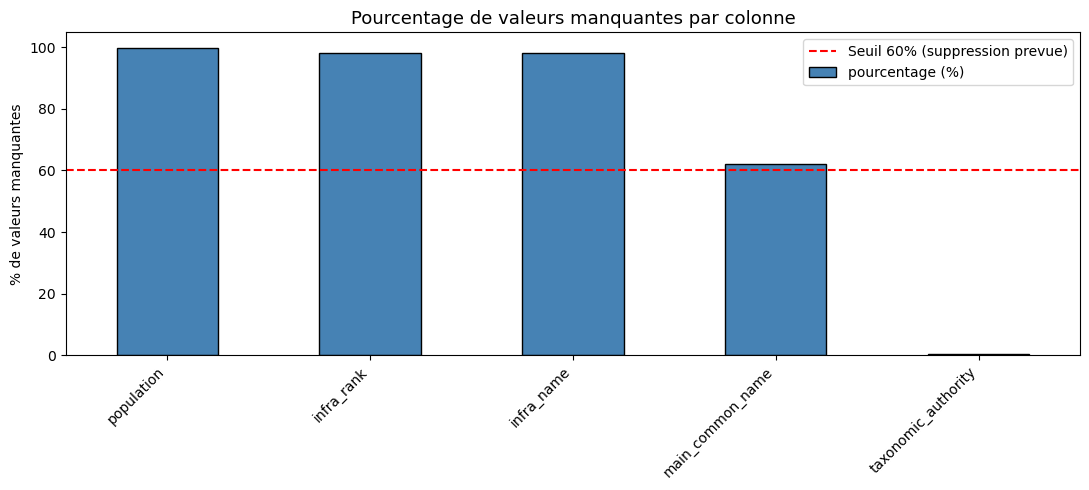

In [8]:
# visualisation des valeurs manquantes
if len(avec_manquants) > 0:
    plt.figure(figsize=(11, 5))
    avec_manquants['pourcentage (%)'].plot(
        kind='bar',
        color='steelblue',
        edgecolor='black'
    )
    plt.axhline(60, color='red', linestyle='--', label='Seuil 60% (suppression prevue)')
    plt.title('Pourcentage de valeurs manquantes par colonne', fontsize=13)
    plt.ylabel('% de valeurs manquantes')
    plt.xlabel('')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Rien a afficher : pas de valeurs manquantes.')

In [9]:
# suppression des colonnes non pertinentes
dataset = dataset.drop(columns=['population', 'infra_rank', 'infra_name'])

# imputation de la colonne 'main_common_name' avec 'Inconnu'
dataset['main_common_name'] = dataset['main_common_name'].fillna('Inconnu')

# imputation de la colonne 'taxonomic_authority' avec la valeur la plus fréquente
mode_val = dataset['taxonomic_authority'].mode()[0]
dataset['taxonomic_authority'] = dataset['taxonomic_authority'].fillna(mode_val)

print(dataset.isnull().sum())

taxonid                0
kingdom_name           0
phylum_name            0
class_name             0
order_name             0
family_name            0
genus_name             0
scientific_name        0
taxonomic_authority    0
category               0
main_common_name       0
dtype: int64


### Varible cible

In [10]:
# detection automatique de la colonne IUCN
mots_cles = ['category', 'status', 'iucn', 'conservation', 'threat', 'red']
candidates = [c for c in dataset.columns if any(kw in c.lower() for kw in mots_cles)]

print('Colonnes candidates pour la variable cible :')
for col in candidates:
    print(f'\n--- {col} ---')
    print(dataset[col].value_counts())

Colonnes candidates pour la variable cible :

--- category ---
category
LC       84901
DD       21172
EN       17826
VU       16247
CR        9586
NT        8662
EX         490
LR/nt      335
LR/lc      176
LR/cd       93
EW          54
Name: count, dtype: int64


In [11]:
# adapter si besoin selon ce qui s'affiche ci-dessus
TARGET_COL = candidates[0] if candidates else 'category'
print(f'Variable cible retenue : {TARGET_COL}')

Variable cible retenue : category


In [12]:
# regroupement des categories IUCN en 3 classes
#   LC, NT -> Non menace
#   VU, EN, CR -> Menace
#   EW, EX -> Disparu
#   DD, NE -> supprimes (pas classifiables)

IUCN_MAPPING = {
    'LC'   : 'Non menace',
    'NT'   : 'Non menace',
    'LR/lc': 'Non menace',
    'LR/cd': 'Non menace',
    'LR/nt': 'Non menace',
    'VU'   : 'Menace',
    'EN'   : 'Menace',
    'CR'   : 'Menace',
    'EW'   : 'Disparu',
    'EX'   : 'Disparu',
}

dataset['label'] = dataset[TARGET_COL].map(IUCN_MAPPING)

nb_avant = len(dataset)
df_filtre = dataset[dataset['label'].notna()].copy()
nb_apres = len(df_filtre)

print(f'Lignes retirees (DD, NE, etc.) : {nb_avant - nb_apres}')
print(f'Observations conservees        : {nb_apres}')
print(f'\nDistribution des 3 classes :')
print(df_filtre['label'].value_counts())

Lignes retirees (DD, NE, etc.) : 21172
Observations conservees        : 138370

Distribution des 3 classes :
label
Non menace    94167
Menace        43659
Disparu         544
Name: count, dtype: int64


### Numérisation des colonnes texte dans un pipeline pour éviter les erreurs après le train
fit → uniquement sur train

transform → sur test

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df_model = df_filtre.copy()

df_model = df_model.dropna(subset=['label']).copy()

X = df_model.drop(columns=['label'])
y = df_model['label']

X = X.drop(columns=['scientific_name', 'taxonomic_authority', 'category'], errors='ignore')

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()

# Pipeline numérique
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline catégoriel
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Préprocesseur global
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)


print("Préprocesseur créé avec succès.")
print("Colonnes numériques :", numeric_cols)
print("Colonnes catégorielles :", categorical_cols)

Préprocesseur créé avec succès.
Colonnes numériques : ['taxonid']
Colonnes catégorielles : ['kingdom_name', 'phylum_name', 'class_name', 'order_name', 'family_name', 'genus_name', 'main_common_name']


### Train/Test Split

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nRépartition y_train :")
print(y_train.value_counts())

Train: (110696, 8) | Test: (27674, 8)

Répartition y_train :
label
Non menace    75334
Menace        34927
Disparu         435
Name: count, dtype: int64


In [15]:
# Vérification de la distribution des classes dans y_train

print("Distribution dans y_train :")
print(pd.Series(y_train).value_counts())
print(pd.Series(y_train).value_counts(normalize=True) * 100)

Distribution dans y_train :
label
Non menace    75334
Menace        34927
Disparu         435
Name: count, dtype: int64
label
Non menace    68.054853
Menace        31.552179
Disparu        0.392968
Name: proportion, dtype: float64


La classe “Disparu” est extrêmement sous-représentée (moins de 1%), ce qui rend nécessaire l’utilisation d’une technique de rééquilibrage telle que SMOTE.

In [ ]:
# après SMOTE (dans debug ou test)
from collections import Counter

X_res, y_res = SMOTE(random_state=42).fit_resample(X_train, y_train)
print(Counter(y_res))

## 2. Réduction de dimension

Ici nous allons utiliser la méthode intégrée de sélection de variables Random Forest. Ainsi on peut garder les variables compréhensibles, on peut garder les variables numérique et catégoriel.

In [17]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

selector = SelectFromModel(
    estimator=RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    threshold='median'
)

print("Sélecteur de features créé avec succès.")

Sélecteur de features créé avec succès.


In [ ]:
# Sélection de variables pour réduire la dimensionnalité et améliorer la performance
temp_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', selector)
])

temp_pipeline.fit(X_train, y_train)

feature_names = temp_pipeline.named_steps['preprocessor'].get_feature_names_out()
mask = temp_pipeline.named_steps['selector'].get_support()

print("Nombre de variables avant :", len(feature_names))
print("Nombre de variables après :", mask.sum())

## 3. Modèles

In [18]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ),
    "SVM": SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
    )
}

trained_models = {}

for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),         # imputation + one-hot + scaling
        ('smote', SMOTE(random_state=42)),      # rééquilibrage seulement sur train
        ('selector', selector),                 # réduction de dimension
        ('classifier', model)                   # modèle final
    ])
    
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline
    
    y_pred = pipeline.predict(X_test)
    print(f"\nModèle : {name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))

### Validation croisée